In [1]:
!pip uninstall odc-stac -y --quiet
!pip install odc-stac --quiet
!pip uninstall pystac-client -y --quiet
!pip install pystac-client --quiet
!pip install -U pystac --quiet

In [2]:
!pip uninstall dea-tools -y --quiet
!pip install dea-tools==0.4.4 --quiet

# Simple Urban Classifier using only SAR 


## Description
1. Load and pre-process Sentinel-1 SAR data
2. Load training data for urban classification from Global Urban Footprint Urban Fraction in the NCI 
3. Train Random Forest Classifier and see results

***

## Getting started

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` directory.

In [3]:
%matplotlib inline

import odc.geo.xr
import datacube
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb
from dea_tools.validation import xr_random_sampling
from dea_tools.classification import collect_training_data
from dea_tools.dask import create_local_dask_cluster

from odc.geo import BoundingBox
from pystac_client import Client
from odc.geo.xr import assign_crs


In [4]:
client = create_local_dask_cluster(return_client=True) # dask is giving issue with smart filter, quick solution is not using dask for now

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 94,Total memory: 665.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46183,Workers: 1
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Total threads: 94
Started: Just now,Total memory: 665.00 GiB
Comm: tcp://127.0.0.1:46377,Total threads: 94
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/42683/status,Memory: 665.00 GiB
Nanny: tcp://127.0.0.1:37837,


2025-09-15 01:12:46,857 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-c6f869fc1a504862bc00b1c8fbd7d8a6' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7f5afbfb11b0>, (Dataset <id=c6f869fc-1a50-4862-bc00-b1c8fbd7d8a6 product=ga_ls_landcover_class_cyear_3 location=s3://dea-public-data/derivative/ga_ls_landcover_class_cyear_3/2-0-0/x62/y30/2024--P1Y/ga_ls_landcover_class_cyear_3_x62y30_2024--P1Y_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7f5afbfb11b0>, (Dataset <id=c6f869fc-1a50-4862-bc00-b1c8fbd7d8a6 product=ga_ls_landcover_class_c

### Environment set up

In [8]:
dc = datacube.Datacube(app="S1")

## View available collections

In [9]:
dc_measurements = dc.list_measurements()
dc_measurements.loc['ga_s1_nrb_iw_vv_vh_0']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
VV_gamma0,VV_gamma0,float32,linear power,NaN,[vv_gamma0],NaN
VH_gamma0,VH_gamma0,float32,linear power,NaN,[vh_gamma0],NaN
mask,mask,uint8,classification,255,NaN,"{'mask': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."
number_of_looks,number_of_looks,float32,count,NaN,"[n_looks, nlooks]",NaN
gamma0_to_beta0_ratio,gamma0_to_beta0_ratio,float32,ratio,NaN,NaN,NaN
gamma0_to_sigma0_ratio,gamma0_to_sigma0_ratio,float32,ratio,NaN,NaN,NaN
local_incidence_angle,local_incidence_angle,float32,degrees,NaN,"[lia, LIA]",NaN
incidence_angle,incidence_angle,float32,degrees,NaN,"[ia, IA]",NaN


## View collection metadata

Displaying the result from `get_collection()` will provide an expandable JSON output showing the collection-level metadata. 

In [10]:
dc.index.products.get_by_name("ga_s1_nrb_iw_hh_c0").fields

{'creation_time': None,
 'format': None,
 'label': None,
 'lat': None,
 'lon': None,
 'time': None,
 'beam_id': None,
 'crs_raw': None,
 'burst_id': None,
 'platform': None,
 'scene_id': None,
 'source_id': None,
 'instrument': None,
 'orbit_file': None,
 'orbit_cycle': None,
 'orbit_state': None,
 'region_code': None,
 'orbit_source': None,
 'conversion_eq': None,
 'absolute_orbit': None,
 'product_family': 'sar_ard',
 'relative_orbit': None,
 'dataset_version': None,
 'instrument_mode': None,
 'measurement_type': None,
 'noise_removal_applied': None,
 'observation_direction': None,
 'measurement_convention': None,
 'speckle_filter_applied': None,
 'far_range_incidence_angle': None,
 'near_range_incidence_angle': None,
 'bistatic_correction_applied': None,
 'ionospheric_correction_applied': None,
 'wet_tropospheric_correction_applied': None,
 'static_tropospheric_correction_applied': None}

## Set search parameters

These are primarily used by the search step, but may also be re-used in load

In [44]:
# Set random seed for reproducibility
rand_state = 42

# Products to query
product_to_load = "ga_s1_nrb_iw_vv_vh_0"

# Area of interest
aoi_bbox = BoundingBox(
    left=148.80,
    bottom=-34.01,
    right= 151.0,
    top=-33.85,
    crs="EPSG:4326"
)

# Date range of interest
start_date = "2024-07-01"
end_date = "2025-06-30"

# Measurements to load
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask"]

# CRS and resolution
output_crs = "EPSG:3577"
output_res = 20 

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

# Display the Area of Interest on a map
aoi_bbox.explore()

## Run load

Note that the load function takes:
* `items`: a pystac-client items_collection
* `bands`: a list of assets to load
* `intersects`: a geometry to intersect
* `crs`: a coordinate reference system for the output
* `resolution`: a resolution for the output
* `groupby`: a method or property to group by
* `chunks`: (optionally) a dictionary describing how to chunk the data for lazy loading (recommended)


In [45]:
ds = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={},
    skip_broken_datasets=True
)

In [46]:
ds

<xarray.Dataset> Size: 25GB
Dimensions:      (time: 117, y: 2297, x: 10143)
Coordinates:
  * time         (time) datetime64[ns] 936B 2024-07-01T19:08:04.991087 ... 20...
  * y            (y) float64 18kB -3.841e+06 -3.841e+06 ... -3.796e+06
  * x            (x) float64 81kB 1.742e+06 1.742e+06 ... 1.539e+06 1.539e+06
    spatial_ref  int32 4B 3577
Data variables:
    VV_gamma0    (time, y, x) float32 11GB dask.array<chunksize=(1, 2297, 10143), meta=np.ndarray>
    VH_gamma0    (time, y, x) float32 11GB dask.array<chunksize=(1, 2297, 10143), meta=np.ndarray>
    mask         (time, y, x) uint8 3GB dask.array<chunksize=(1, 2297, 10143), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Process the data

* Speckle filter

We will use a standard speckle filter

* Masking

The GA Sentinel-1 backscatter product comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.

* Generate summary statistics


In [47]:
# standard filter
import requests
url_std = 'https://raw.githubusercontent.com/cbur24/sentinel-1-hackathon/refs/heads/speckle_filters/src/speckle_filters.py'
code_std = requests.get(url_std).text
exec(code_std)

In [48]:
def process_cube(ds):
    ds["VV_gamma0_filtered"] = apply_lee_filter(ds["VV_gamma0"], size=3)
    ds["VH_gamma0_filtered"] = apply_lee_filter(ds["VH_gamma0"], size=3)

    ds["VV_gamma0_masked"] = xr.where(ds.mask == 0, ds["VV_gamma0_filtered"], np.nan)
    ds["VH_gamma0_masked"] = xr.where(ds.mask == 0, ds["VH_gamma0_filtered"], np.nan)

    ds_reduced = ds.drop_vars([
        'VV_gamma0', 'VH_gamma0', 'mask',
        'VV_gamma0_filtered', 'VH_gamma0_filtered'
    ])

    ds_grouped = ds_reduced.groupby('time.month')
    ds_final = ds_grouped.mean().drop_vars(['VV_gamma0_masked', 'VH_gamma0_masked'])

    ds_final['mean_vv'] = ds_grouped.mean()['VV_gamma0_masked']
    ds_final['mean_vh'] = ds_grouped.mean()['VH_gamma0_masked']
    ds_final['max_vv'] = ds_grouped.max()['VV_gamma0_masked']
    ds_final['max_vh'] = ds_grouped.max()['VH_gamma0_masked']
    ds_final['min_vv'] = ds_grouped.min()['VV_gamma0_masked']
    ds_final['min_vh'] = ds_grouped.min()['VH_gamma0_masked']
    ds_final['std_vv'] = ds_grouped.std()['VV_gamma0_masked']
    ds_final['std_vh'] = ds_grouped.std()['VH_gamma0_masked']

    return ds_final


In [49]:
ds_final = process_cube(ds)

In [50]:
ds_final = ds_final.compute()

## Open and pre-process training data file

In [51]:
urban_GUF = xr.open_dataarray('https://thredds.nci.org.au/thredds/dodsC/ub8/au/LandCover/OzWALD_LC/GUF_FractionUrban_Australia.nc')
urban_GUF = urban_GUF.transpose('latitude', 'longitude')
urban_GUF = assign_crs(urban_GUF, crs='EPSG:4326')

In [52]:
urban_GUF_box = urban_GUF.odc.reproject(how=ds.odc.geobox, resampling='bilinear')
urban = xr.where(urban_GUF_box>70, 1, 0) # consider urban when more than 70% confidence
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

In [53]:
# xr_random_sampling() uses random choice from numpy, so we will set the seed for numpy random operations 
np.random.seed(rand_state)
train_points = xr_random_sampling(urban, sampling='manual', manual_class_ratios={'1':500, '0':500})

Class 1: sampling 500 points
Class 0: sampling 500 points


In [54]:
train_points['class'] = train_points['class'].astype(int)

<Axes: >

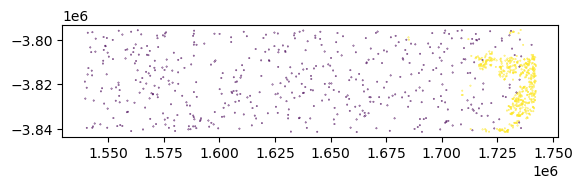

In [55]:
train_points.plot(column='class', markersize=.1)

## Create dataframe to train model

In [56]:
cols = ['urban'] + [f'{stat}_{band}_{month}' for stat in ['mean','max','min','std'] for band in ['vv', 'vh'] for month in range(1,13)]
#cols = ['urban'] + [f'{stat}_{band}_{month}' for stat in ['mean','std'] for band in ['vv', 'vh'] for month in range(1,13)]

train_df = pd.DataFrame(columns=cols, index=range(len(train_points)))

In [57]:
for i, (c, g) in enumerate(zip(train_points['class'], train_points.geometry)):
    print(i, end='\r')
    ds_point = ds_final.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    train_df.loc[i,'urban'] = c
    
    for col in train_df.columns[1:]:
        var = '_'.join(col.split('_')[:-1])
        month = int(col.split('_')[-1])

        train_df.loc[i, col] = ds_point.sel( month=month)[var].data

In [58]:
train_df.to_csv('samples_df_updated.csv',index=False)

## Split train/test

In [59]:
from sklearn.model_selection import StratifiedShuffleSplit

In [60]:
# apply stratified sampling
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=.2, random_state=rand_state)
for train_index, test_index in strat_split.split(train_df, train_df['urban']):
    train_final = train_df.loc[train_index].copy() 
    test_final = train_df.loc[test_index].copy() 

In [61]:
predictors = cols[1:]
print(', '.join(predictors))

mean_vv_1, mean_vv_2, mean_vv_3, mean_vv_4, mean_vv_5, mean_vv_6, mean_vv_7, mean_vv_8, mean_vv_9, mean_vv_10, mean_vv_11, mean_vv_12, mean_vh_1, mean_vh_2, mean_vh_3, mean_vh_4, mean_vh_5, mean_vh_6, mean_vh_7, mean_vh_8, mean_vh_9, mean_vh_10, mean_vh_11, mean_vh_12, max_vv_1, max_vv_2, max_vv_3, max_vv_4, max_vv_5, max_vv_6, max_vv_7, max_vv_8, max_vv_9, max_vv_10, max_vv_11, max_vv_12, max_vh_1, max_vh_2, max_vh_3, max_vh_4, max_vh_5, max_vh_6, max_vh_7, max_vh_8, max_vh_9, max_vh_10, max_vh_11, max_vh_12, min_vv_1, min_vv_2, min_vv_3, min_vv_4, min_vv_5, min_vv_6, min_vv_7, min_vv_8, min_vv_9, min_vv_10, min_vv_11, min_vv_12, min_vh_1, min_vh_2, min_vh_3, min_vh_4, min_vh_5, min_vh_6, min_vh_7, min_vh_8, min_vh_9, min_vh_10, min_vh_11, min_vh_12, std_vv_1, std_vv_2, std_vv_3, std_vv_4, std_vv_5, std_vv_6, std_vv_7, std_vv_8, std_vv_9, std_vv_10, std_vv_11, std_vv_12, std_vh_1, std_vh_2, std_vh_3, std_vh_4, std_vh_5, std_vh_6, std_vh_7, std_vh_8, std_vh_9, std_vh_10, std_vh_11, std

In [62]:
# define response and explanatory vars train_final dataset
resp_train = train_final['urban'].astype(int).copy() 
expl_train = train_final[predictors].copy()

# define response and explanatory for test_final dataset
resp_test = test_final['urban'].astype(int).copy() 
expl_test = test_final[predictors].copy()

print(f'Train count: {len(resp_train.index)}')
print(f'Test count: {len(resp_test.index)}')

Train count: 800
Test count: 200


## Random forest classifier

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

In [64]:
rf = RandomForestClassifier(n_jobs=-1, random_state=rand_state)

In [65]:
# ranges of possible hyperparameters
hyperpar = {'n_estimators': randint(low=10,high=150),  
            'criterion': ['gini','entropy','log_loss'], 
            'max_depth': randint(low=5,high=30), 
            'min_samples_split': randint(low=2,high=30), 
            'min_samples_leaf': randint(low=1,high=20),
            'max_features': randint(low=1,high=len(predictors)), 
            'bootstrap': [True],
            }

In [66]:
from sklearn.metrics import make_scorer, precision_score

rf_rand_search = RandomizedSearchCV(
    rf, 
    param_distributions=hyperpar, 
    n_iter=200, # try 200 hyperparameters combos
    scoring='f1', 
    cv=4, 
    verbose= 1, 
    n_jobs=-1,
    random_state=rand_state
)
                                    
rf_rand_search.fit(expl_train, resp_train)

Fitting 4 folds for each of 200 candidates, totalling 800 fits


RandomizedSearchCV(cv=4,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f5e5990c490>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f5e5990cee0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f5e5990cb80>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f5e5990d270>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f5e5990e470>},
                   random_state=42, scoring='f1', verbose=1)

In [67]:
# best model and score of best model
rf_rand_search.best_params_, rf_rand_search.best_score_

({'bootstrap': True,
  'criterion': 'log_loss',
  'max_depth': 21,
  'max_features': 72,
  'min_samples_leaf': 4,
  'min_samples_split': 7,
  'n_estimators': 113},
 0.823618751965731)

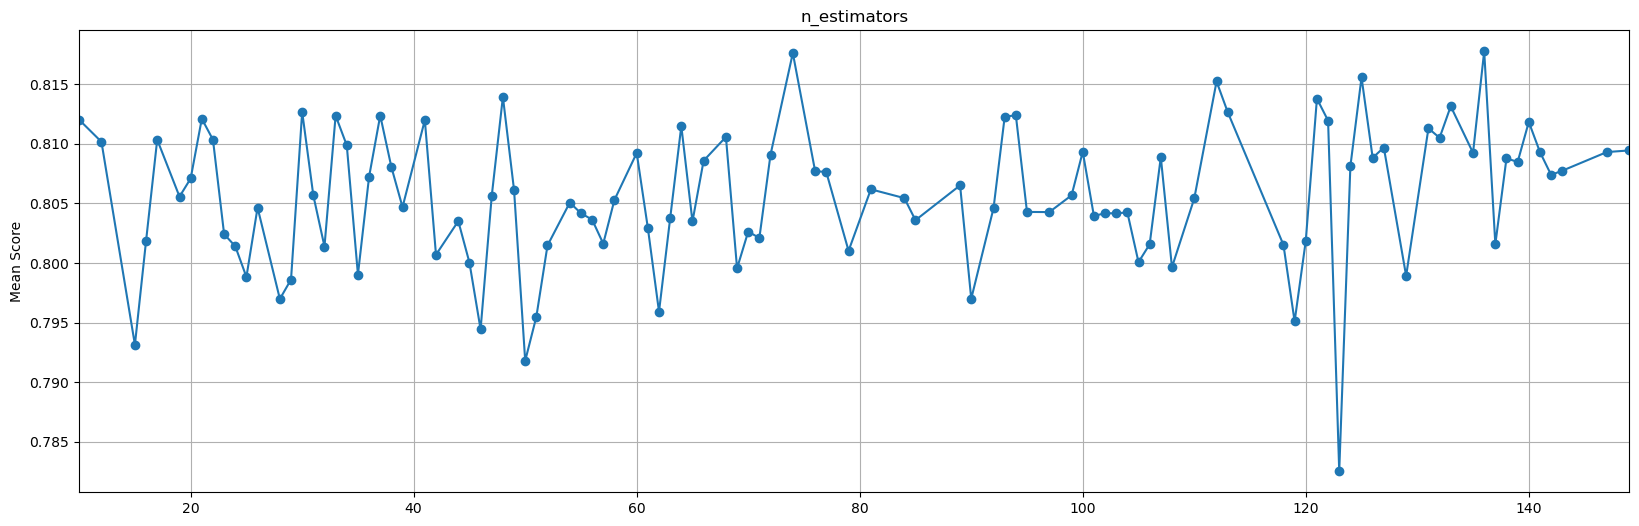

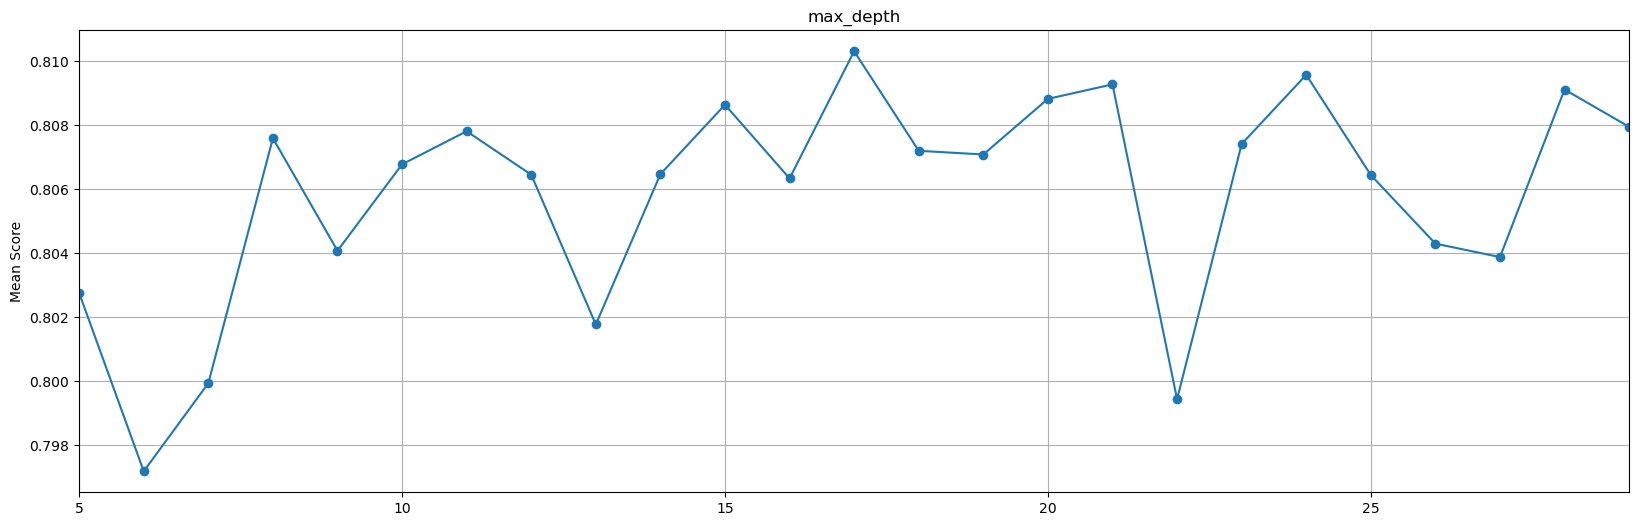

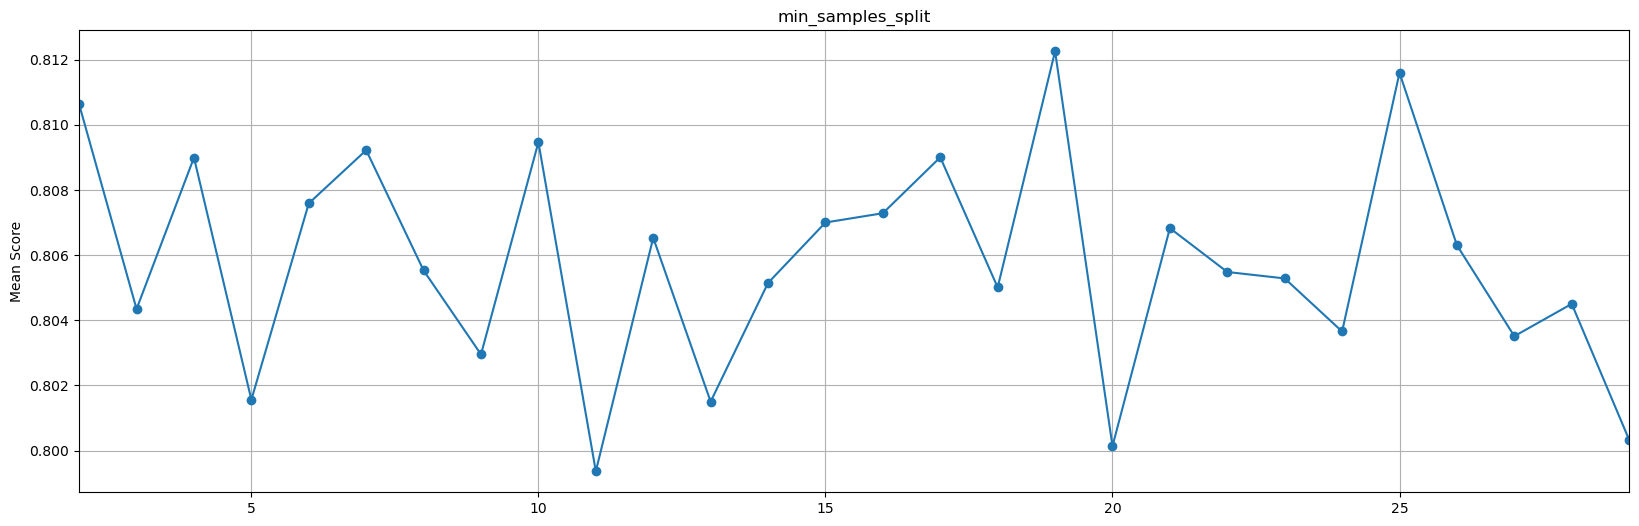

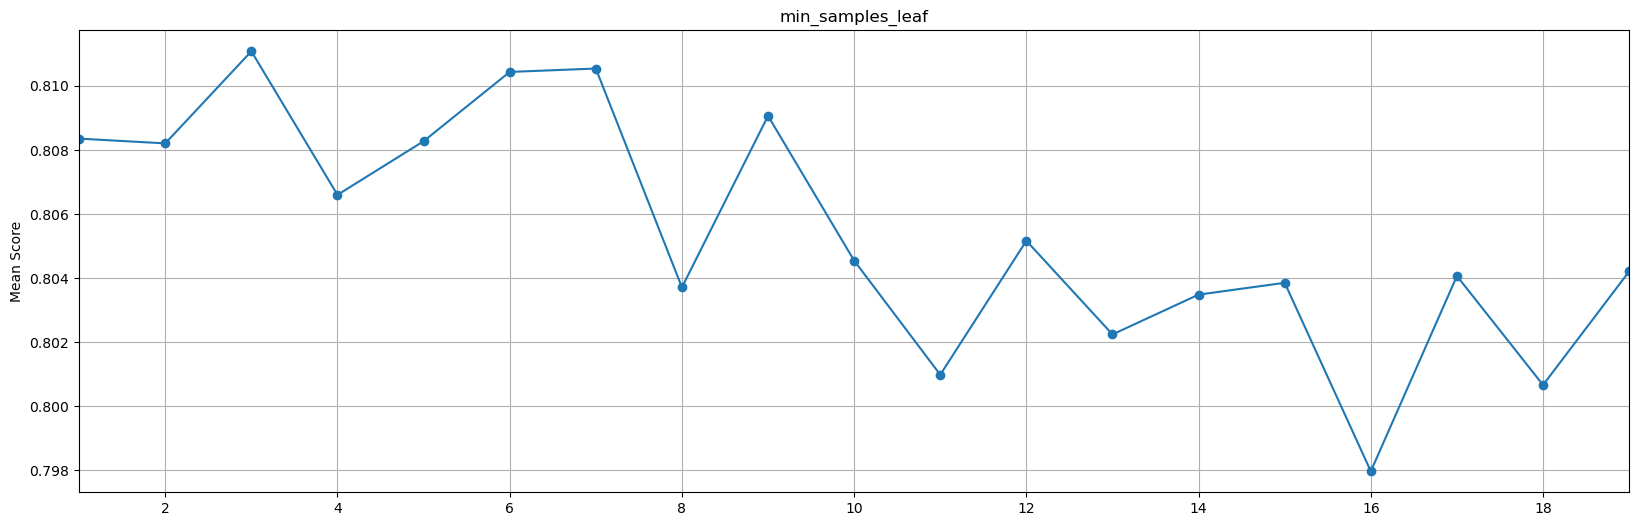

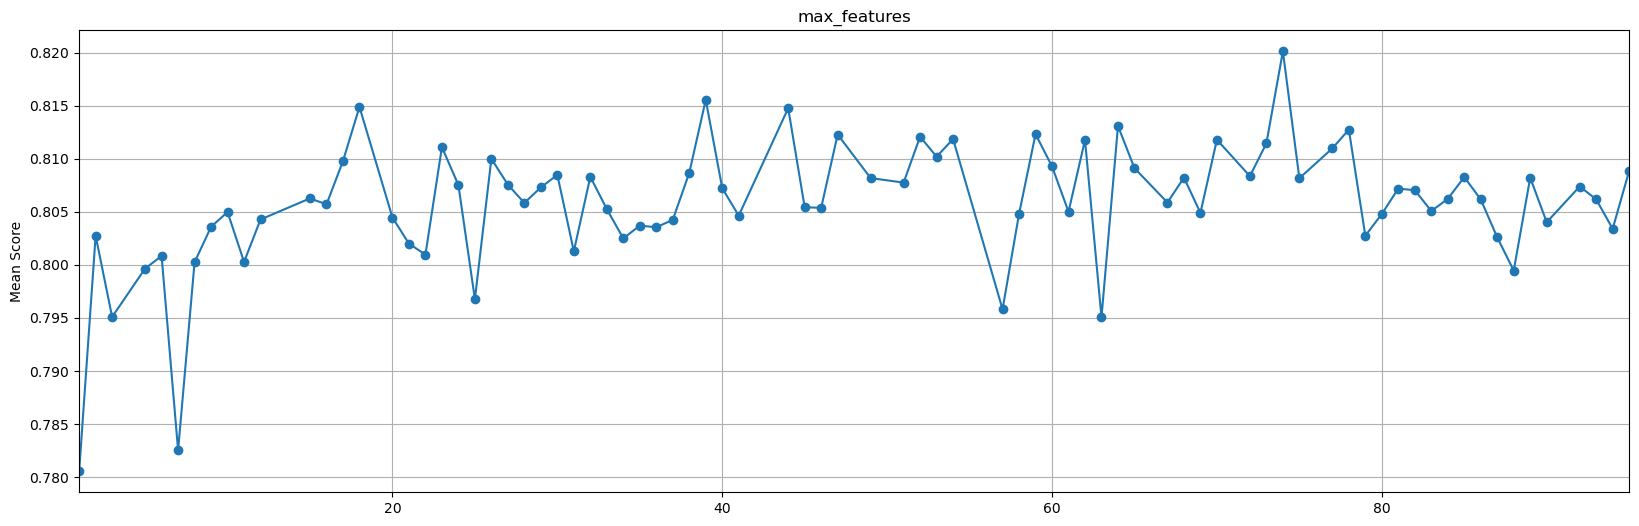

In [68]:
hyperparameters = ['n_estimators','max_depth','min_samples_split','min_samples_leaf','max_features'] 

for hyperparam_name in hyperparameters:
    
    hyperparam_values = rf_rand_search.cv_results_['param_' + hyperparam_name] 
    mean_scores = rf_rand_search.cv_results_['mean_test_score']
    
    # extract all scores for each hyperparameter value 
    hyperparam_tot_scores = dict()
    for value, score in zip(hyperparam_values, mean_scores):
        if value not in hyperparam_tot_scores: 
            hyperparam_tot_scores[value] = [score]
        else:
            hyperparam_tot_scores[value].append(score) 
    
    # mean scores for each hyperparameter value
    sorted_hyperparams = sorted(hyperparam_tot_scores.keys())
    averaged_scores = [np.nanmean(hyperparam_tot_scores[val]) for val in sorted_hyperparams]

    plt.figure(figsize=(20, 6))
    plt.plot(sorted_hyperparams, averaged_scores, marker='o', linestyle='-')

    plt.xlim([min(sorted_hyperparams), max(sorted_hyperparams)])
    plt.ylabel('Mean Score')
    plt.title(f'{hyperparam_name}')
    plt.grid(True)

    plt.show()

In [69]:
hyperpar = {
    'n_estimators': [20,40,60],  
    'criterion': ['log_loss'],  
    'max_depth': [10,15], 
    'min_samples_split': [4,7,10],  
    'min_samples_leaf':[3,5,7],  
    'max_features': [20,40],
    'bootstrap': [True], 
}

# search all combinations of above values
rf_grid_search = GridSearchCV(rf, 
                              param_grid=hyperpar, 
                              scoring='f1', 
                              cv=4, 
                              verbose=1, 
                              n_jobs=-1)

rf_grid_search.fit(expl_train, resp_train)

Fitting 4 folds for each of 108 candidates, totalling 432 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['log_loss'],
                         'max_depth': [10, 15], 'max_features': [20, 40],
                         'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [4, 7, 10],
                         'n_estimators': [20, 40, 60]},
             scoring='f1', verbose=1)

In [70]:
rf_grid_search.best_params_, rf_grid_search.best_score_ 

({'bootstrap': True,
  'criterion': 'log_loss',
  'max_depth': 10,
  'max_features': 40,
  'min_samples_leaf': 3,
  'min_samples_split': 10,
  'n_estimators': 40},
 0.8228884884401811)

In [71]:
# best model
rf_best = rf_grid_search.best_estimator_

In [72]:
# save best model
from joblib import dump
dump(rf_best, f'RF_urban_classifier_updated.joblib')

['RF_urban_classifier_updated.joblib']

### Feature importance

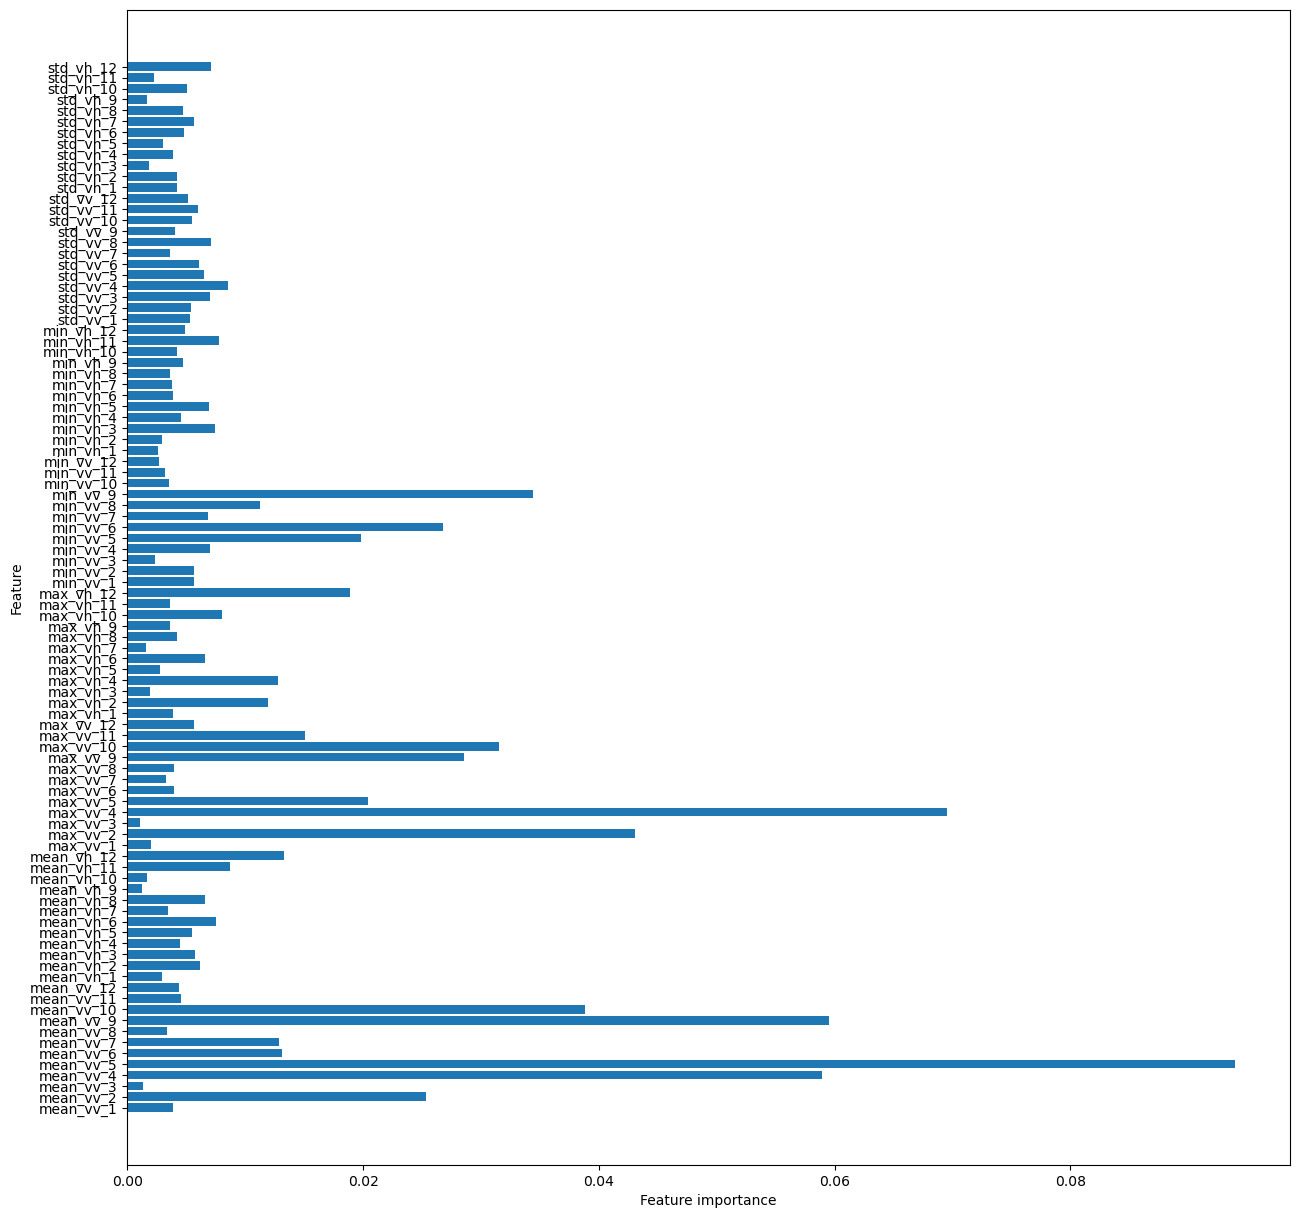

In [73]:
feat_importances = rf_best.feature_importances_
rf_importance = zip(predictors, feat_importances)
    
plt.figure(figsize=(15, 15))
plt.barh(predictors, feat_importances)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.show()

## Model performance 

### Same area of training data

In [74]:
# define functions to generate 2D arrays of estimated urban area

def flatten_months(ds):
    months = ds['month'].values

    new_vars = {}
    for var in ds.data_vars:
        for i in range(ds.sizes['month']):
            mlabel = months[i]
            label = f"{int(mlabel)}"
            
            da = ds[var].isel(month=i)

            da = da.reset_coords('month', drop=True)

            new_vars[f"{var}_{label}"] = da

    return xr.Dataset(new_vars)



def get_estimated_urban_array(ds, predictors, model, ds_already_preprocessed=False, speckle_filter='standard'):

    ds_final = ds
    
    if ds_already_preprocessed == False:
        ds_final = process_cube(ds, speckle_filter)
        ds_final = ds_final.compute()

    ds_final = flatten_months(ds_final)

    ds_final = ds_final.sortby('x')  # west to east
    ds_final = ds_final.sortby('y', ascending=False)  # north to south

    input_array = ds_final[predictors].to_array().values
    nan_mask = np.isnan(input_array)
    nan_mask_2d = np.sum(np.where(nan_mask, 1, 0), axis=0)
    input_array = np.where(nan_mask, 0, input_array) # replace NaN with zeros to run model without issues

    n_vars, y_size, x_size = input_array.shape
    input_rf = input_array.reshape((n_vars, -1)).swapaxes(0, 1)

    predicted_urban = model.predict(input_rf)
    predicted_urban_2d = predicted_urban.reshape((y_size, x_size))
    predicted_urban_2d = np.where(nan_mask_2d > 0, np.nan, predicted_urban_2d) # put back NaNs, if there were any

    # format array as datarray with coords and georeferenced
    out_da = xr.DataArray(
        predicted_urban_2d,
        dims=('y', 'x'),
        coords={'y': ds_final['y'].values, 'x': ds_final['x'].values},
        name='predicted_urban'
    )
    crs = ds_final.odc.crs
    out_da = assign_crs(out_da, crs)

    return out_da


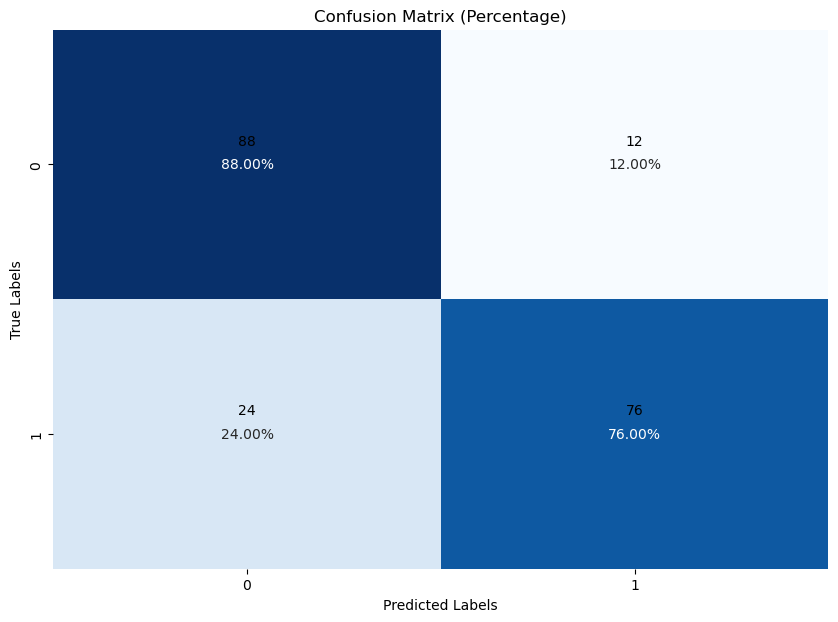

Accuracy: 0.8200
Weighted F1 Score: 0.8193
Weighted Precision: 0.8247
Weighted Recall: 0.8200


In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score, classification_report, average_precision_score
import seaborn as sns 

# true labels and predictions
y_true = resp_test
y_pred = rf_best.predict(expl_test[predictors])

cm = confusion_matrix(y_true, y_pred)

# show percentages (recall)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix (Percentage)')

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n', 
                ha='center', va='bottom', color='black')

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

In [76]:
# classification summary 
report = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision  recall  f1-score  support
0              0.785714    0.88  0.830189   100.00
1              0.863636    0.76  0.808511   100.00
accuracy       0.820000    0.82  0.820000     0.82
macro avg      0.824675    0.82  0.819350   200.00
weighted avg   0.824675    0.82  0.819350   200.00


### Different area

In [125]:
# Area of interest
aoi_bbox = BoundingBox(
    left=149.108304,
    bottom=-35.408159,
    right= 149.184827,
    top=-35.322674,
    crs="EPSG:4326"
)
aoi_bbox.explore()

In [130]:
ds_test = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={},
    skip_broken_datasets=True
)
ds_test

<xarray.Dataset> Size: 109MB
Dimensions:      (time: 57, y: 518, x: 409)
Coordinates:
  * time         (time) datetime64[ns] 456B 2024-07-06T19:16:41.558207 ... 20...
  * y            (y) float64 4kB -3.972e+06 -3.972e+06 ... -3.962e+06 -3.962e+06
  * x            (x) float64 3kB 1.555e+06 1.555e+06 ... 1.547e+06 1.547e+06
    spatial_ref  int32 4B 3577
Data variables:
    VV_gamma0    (time, y, x) float32 48MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    VH_gamma0    (time, y, x) float32 48MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    mask         (time, y, x) uint8 12MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [131]:
ds_test = process_cube(ds_test).compute()
urban_test = get_estimated_urban_array(ds_test, predictors, rf_best, ds_already_preprocessed=True)
# this produces a warning, because RF was trained with feature labels, however the order or predictors is always the same
# because coming from variable "predictors", so model can run anyway. Although it's not really best practice

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [132]:
# get some points from new ROI
urban_GUF_box = urban_GUF.odc.reproject(how=lc_test.odc.geobox, resampling='bilinear')
urban = xr.where(urban_GUF_box>90, 1, 0) # consider urban when more than 90% confidence - As it was noticed that below this the classification of these reference data appeared quite wrong for this ROI
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

np.random.seed(rand_state)
test_points = xr_random_sampling(urban, sampling='manual', manual_class_ratios={'1':50, '0':50})
test_points['class'] = test_points['class'].astype(int)

test_df = pd.DataFrame(columns=cols, index=range(len(test_points)))

for i, (c, g) in enumerate(zip(test_points['class'], test_points.geometry)):
    print(i+1, end='\r')
    ds_point = ds_test.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    test_df.loc[i,'urban'] = c
    
    for col in test_df.columns[1:]:
        var = '_'.join(col.split('_')[:-1])
        month = int(col.split('_')[-1])

        test_df.loc[i, col] = ds_point.sel(month=month)[var].data

test_df.to_csv('test_samples_updated.csv',index=False)


# split response and explanatory vars
resp_test = test_df['urban'].astype(int).copy() 
expl_test = test_df[predictors].copy()

Class 1: sampling 50 points
Class 0: sampling 50 points


In [133]:
# load geomedian to show side by side with classification
rgb_test = dc.load(
    product=['ga_ls8cls9c_gm_cyear_3'],
    measurements=['nbart_red','nbart_green','nbart_blue'],
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=('2024-01-01', '2024-12-31'),
    dask_chunks={},
    skip_broken_datasets=True
)

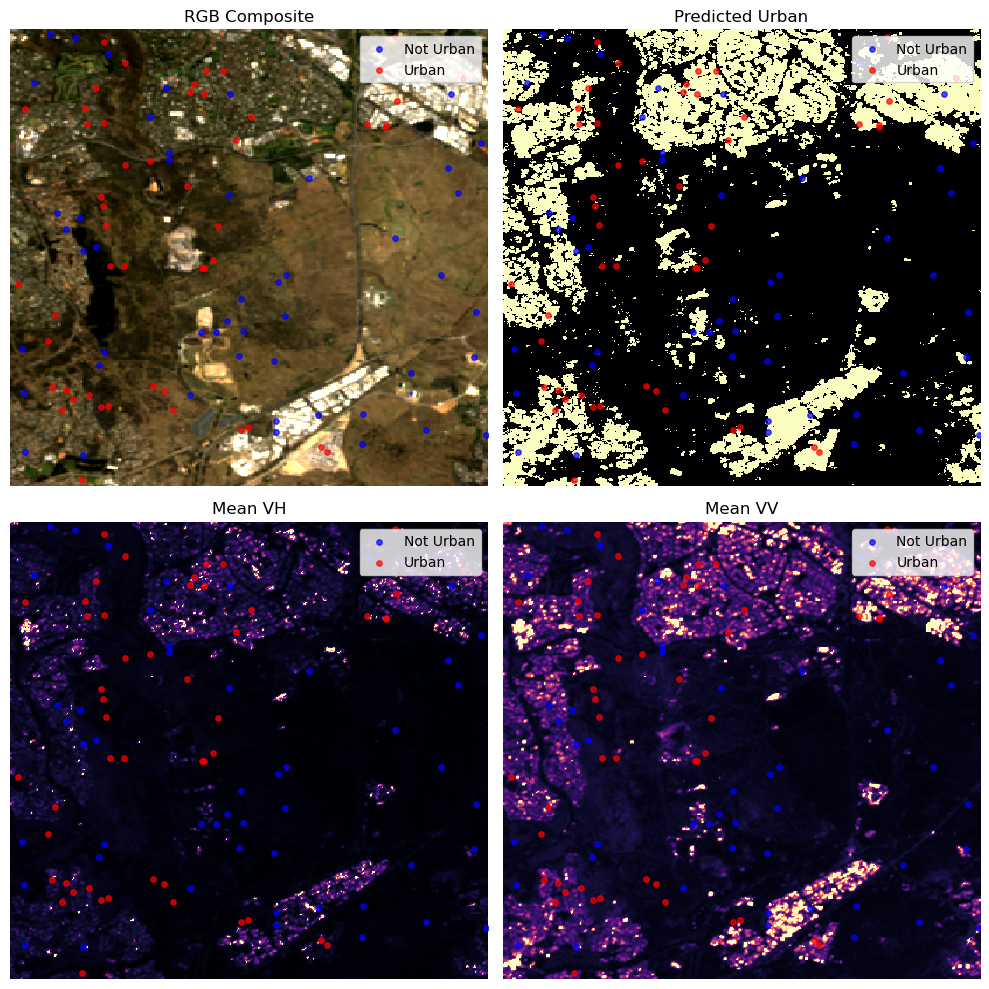

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Plot RGB composite
rgb = rgb_test.isel(time=0)[['nbart_red', 'nbart_green', 'nbart_blue']].to_array()
rgb.plot.imshow(ax=axes[0, 0], robust=True)
axes[0, 0].set_title('RGB Composite')
axes[0, 0].axis("off")

# Plot predicted urban
urban_test.plot.imshow(ax=axes[0, 1], cmap='magma', add_colorbar=False)
axes[0, 1].set_title('Predicted Urban')
axes[0, 1].axis("off")

# Plot Mean VH 
ds_test['mean_vh'].mean(dim='month').plot.imshow(ax=axes[1, 0], cmap='magma', add_colorbar=False, vmax=.5)
axes[1, 0].set_title('Mean VH')
axes[1, 0].axis("off")

# Plot Mean VV 
ds_test['mean_vv'].mean(dim='month').plot.imshow(ax=axes[1, 1], cmap='magma', add_colorbar=False, vmax=1)
axes[1, 1].set_title('Mean VV')
axes[1, 1].axis("off")


x_coords = test_points.geometry.x
y_coords = test_points.geometry.y

# Class label mapping and colors
class_labels = {0: 'Not Urban', 1: 'Urban'}
colors = {0: 'blue', 1: 'red'}

# Overlay points on all subplots
for ax in axes.flatten():
    handles = []
    labels = []
    for cls in [0, 1]:
        mask = test_points['class'] == cls
        sc = ax.scatter(x_coords[mask], y_coords[mask], c=colors[cls], s=15, alpha=0.7, label=class_labels[cls])
        handles.append(sc)
        labels.append(class_labels[cls])
    # Add legend to each subplot
    ax.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()


In [135]:
# Save to NetCDF
urban_test_wgs84 = urban_test.rio.reproject("EPSG:4326")
urban_test_wgs84.to_netcdf("predicted_urban_wgs84_updated.nc")

mean_vh_2d_wgs84 = mean_vh_2d.rio.reproject("EPSG:4326")
mean_vh_2d_wgs84.to_netcdf("mean_vh_2d_wgs84_updated.nc")

mean_vv_2d_wgs84 = mean_vv_2d.rio.reproject("EPSG:4326")
mean_vv_2d_wgs84.to_netcdf("mean_vv_2d_wgs84_updated.nc")

In [136]:
# convert classificiation to vector
import geopandas as gpd
import rasterio.features
from shapely.geometry import shape

data = urban_test_wgs84.values
transform = urban_test_wgs84.rio.transform()

# get shapes where value == 1, ie urban
shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)
urban_shapes = [
    {"geometry": shape(geom), "properties": {"value": value}}
    for geom, value in shapes
    if value == 1
]

gdf = gpd.GeoDataFrame.from_features(urban_shapes, crs="EPSG:4326")

gdf.to_file("predicted_urban_updated.geojson", driver="GeoJSON")


/tmp/ipykernel_801/3222167226.py:10: RuntimeWarning: invalid value encountered in cast
  shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)


### Compare with current DEA Land Cover

In [137]:
# load landcover
lc_test = dc.load(
    product=['ga_ls_landcover_class_cyear_3'],
    measurements=['level3'],
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(30, -30), # NB: res is different from S1
    time=('2024-01-01', '2024-12-31'),
    dask_chunks={},
    skip_broken_datasets=True
)

# urban mask: 1 where landcover is 215 (ie artificial), else 0
urban_mask = (lc_test == 215).astype(np.uint8)

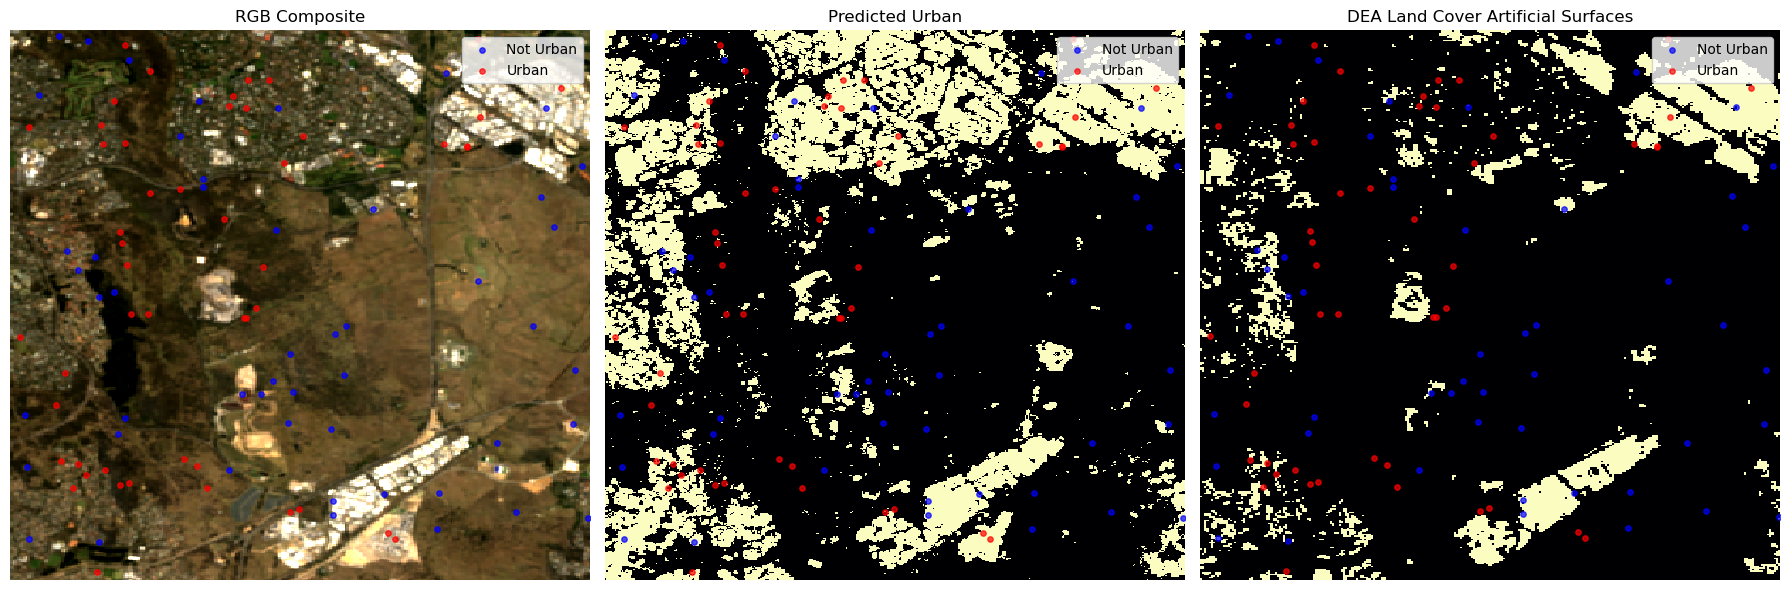

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot RGB composite
rgb.plot.imshow(ax=axes[0], robust=True)
axes[0].set_title('RGB Composite')
axes[0].axis("off")

# Plot predicted urban
urban_test.plot.imshow(ax=axes[1], cmap='magma', add_colorbar=False)
axes[1].set_title('Predicted Urban')
axes[1].axis("off")

# Plot artificial mask from DEA LC
urban_mask['level3'].isel(time=0).plot.imshow(ax=axes[2], cmap='magma', add_colorbar=False)
axes[2].set_title('DEA Land Cover Artificial Surfaces')
axes[2].axis("off")

x_coords = test_points.geometry.x
y_coords = test_points.geometry.y

# Define class label mapping and colors
class_labels = {0: 'Not Urban', 1: 'Urban'}
colors = {0: 'blue', 1: 'red'}

# Overlay points on all plots
for ax in axes:
    handles = []
    labels = []
    for cls in [0, 1]:
        mask = test_points['class'] == cls
        sc = ax.scatter(x_coords[mask], y_coords[mask], c=colors[cls], s=15, alpha=0.7, label=class_labels[cls])
        handles.append(sc)
        labels.append(class_labels[cls])
    # Add legend to each subplot
    ax.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()


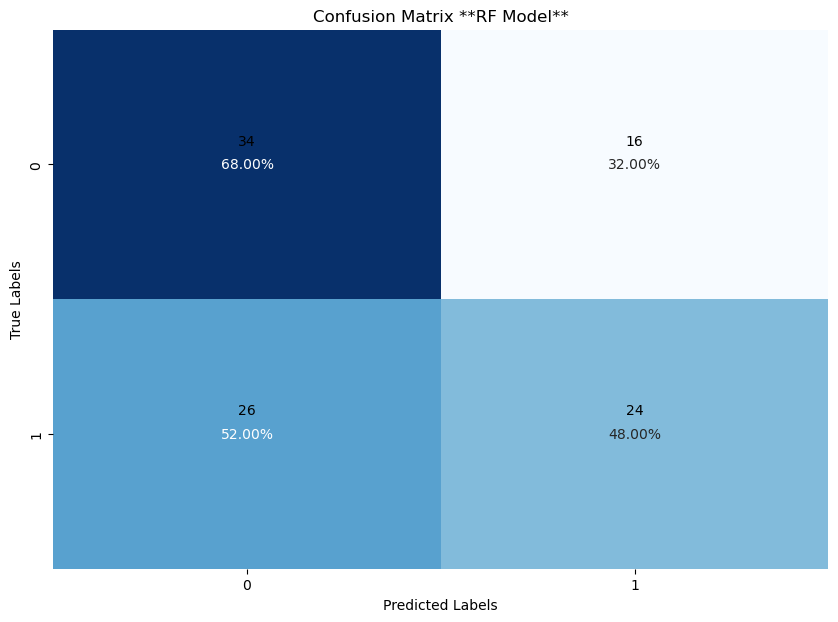

Accuracy: 0.5800
Weighted F1 Score: 0.5758
Weighted Precision: 0.5833
Weighted Recall: 0.5800


In [139]:
# true labels and predictions
y_true = resp_test
y_pred = rf_best.predict(expl_test[predictors])

cm = confusion_matrix(y_true, y_pred)

# show percentages (recall)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix **RF Model**')

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n', 
                ha='center', va='bottom', color='black')

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

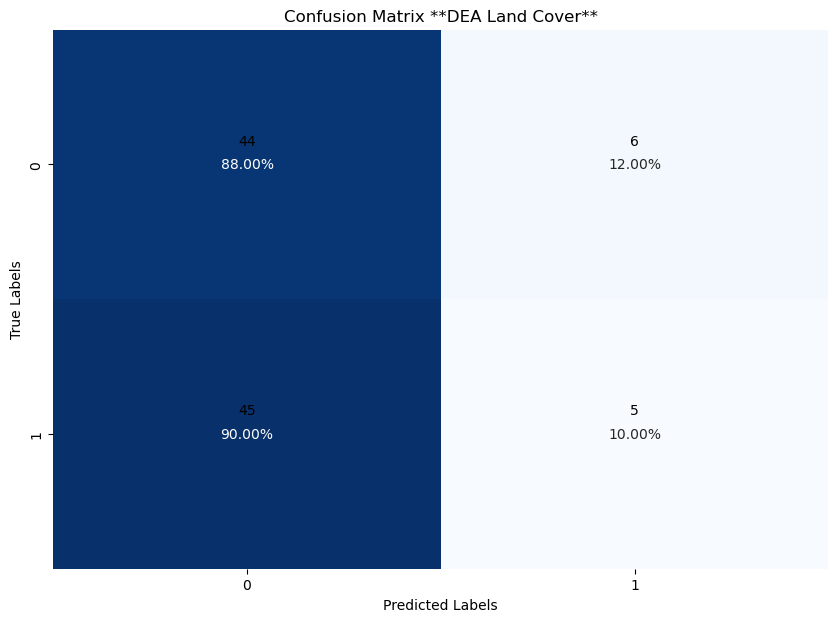

Accuracy: 0.4900
Weighted F1 Score: 0.3985
Weighted Precision: 0.4745
Weighted Recall: 0.4900


In [140]:

# Extract urban mask values at test points
mask_values = []
for g in test_points.geometry:
    val = urban_mask.sel(x=g.x, y=g.y, method="nearest").level3.data
    mask_values.append(int(val))

mask_values = pd.Series(mask_values, name='urban_mask')

# True labels from your test dataframe
y_true = test_df['urban'].astype(int)
y_pred_mask = mask_values

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_mask)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix **DEA Land Cover**')

# Add counts inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f'{cm[i, j]}\n', ha='center', va='bottom', color='black')

plt.show()

# Calculate performance metrics
accuracy = accuracy_score(y_true, y_pred_mask)
f1_weighted = f1_score(y_true, y_pred_mask, average='weighted')
precision_weighted = precision_score(y_true, y_pred_mask, average='weighted')
recall_weighted = recall_score(y_true, y_pred_mask, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

The RF model seems to do a bit better to estimate urban pixels, however the reference data (GUF) does not seem too accurate either when observing the location of the GUF points over the RGB geomedian. Validation and/or re-training using alternative input data is advisable. 

### Example screenshots for comparison of models

These screenshots where created in the DEA Maps. It is possible to check the results interactively by clicking the URL below and uploading the geojson file of the RF classification, saved above.
https://maps.dea.ga.gov.au/#share=s-aSSXqmIROW5BLC8XDDfdUop1OCm

The semi-transparent teal layer is the RF model prediction, below is a Sentinel-2 RGB of a clear day in Feb 2025, or the DEA LC classification (Artificial Surfaces are in pink/red)

![](./RF-urban-RGB-1.PNG)

![](./RF-urban-deaLC-1.PNG)

![](./RF-urban-RGB-3.PNG)

![](./RF-urban-deaLC-3.PNG)

![](./RF-urban-RGB-2.PNG)

![](./RF-urban-deaLC-2.PNG)